# Personality Prediction

# Import Necessary Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
import numpy as np
import joblib

# Load the Dataset

In [4]:
df=pd.read_csv(r'C:\Users\HP\Desktop\data analytics\1projects\ml\personality_synthetic_dataset.csv')

# Understanding of Data

In [5]:
df.head()

,personality_type,social_energy,alone_time_preference,talkativeness,deep_reflection,group_comfort,party_liking,listening_skill,empathy,creativity,...,spontaneity,adventurousness,reading_habit,sports_interest,online_social_usage,travel_desire,gadget_usage,work_style_collaborative,decision_speed,stress_handling
0,Extrovert,6.794295,3.854670,8.725446,2.515151,7.097368,8.588762,6.774799,6.430132,6.142968,...,4.853313,8.257134,5.270555,10.000000,9.154296,4.816422,9.191711,8.313590,8.032376,7.176905
1,Ambivert,6.378988,5.731157,7.029529,7.274493,4.111199,3.258248,5.550909,3.958179,6.149457,...,6.067201,6.289347,5.753165,5.334303,4.683781,4.725666,5.956141,5.890619,3.158988,3.423577
2,Ambivert,7.459421,6.322263,3.922269,4.622261,5.343276,7.452152,9.483990,6.127654,7.032017,...,5.524244,9.238784,5.250405,3.153540,5.000338,6.139166,6.033048,5.807500,4.571003,5.647480
3,Extrovert,6.159626,3.097837,6.019093,1.965440,7.837140,10.000000,9.436733,8.949684,8.923875,...,4.327018,8.489791,5.312617,8.379936,7.601946,6.370056,5.410145,6.671781,6.600233,5.870088
4,Introvert,5.568462,6.986722,3.913240,9.926161,1.650483,0.362298,7.470387,6.756837,9.507803,...,5.187689,3.167217,7.060235,2.333388,7.771569,5.534336,5.704598,5.832968,5.813099,3.758084


In [6]:
df.tail()

,personality_type,social_energy,alone_time_preference,talkativeness,deep_reflection,group_comfort,party_liking,listening_skill,empathy,creativity,...,spontaneity,adventurousness,reading_habit,sports_interest,online_social_usage,travel_desire,gadget_usage,work_style_collaborative,decision_speed,stress_handling
19995,Ambivert,3.783857,4.345803,8.220063,6.297798,5.162622,5.702266,5.518356,3.420139,5.811565,...,8.521256,4.355973,6.454815,2.557365,6.949292,4.176390,5.649897,5.665498,5.252077,4.297520
19996,Introvert,2.621406,8.152097,2.954341,8.791467,2.670252,2.931244,5.855202,5.044124,6.244061,...,4.818308,2.631298,10.000000,3.697801,3.217559,3.638815,5.177155,5.106628,0.982214,5.873321
19997,Introvert,0.039689,8.277160,5.728101,7.790080,3.427897,0.708457,7.099321,5.784592,5.400400,...,3.318511,4.071008,9.974147,2.954407,5.427296,6.270830,3.793430,5.009167,3.810962,5.678412
19998,Extrovert,7.756725,3.956191,8.906972,3.793775,7.608467,6.292705,6.824980,5.653421,7.347820,...,7.156525,8.148780,3.840900,6.093418,7.814507,8.428745,8.736932,8.060841,8.161087,5.941793
19999,Introvert,3.225794,8.058594,0.000000,10.000000,6.363376,0.242722,9.307219,7.621912,5.919581,...,5.097344,2.720616,7.344312,5.566736,6.350940,2.997643,5.991222,3.964673,1.967942,5.810435


In [7]:
df.columns

Index(['personality_type', 'social_energy', 'alone_time_preference',
       'talkativeness', 'deep_reflection', 'group_comfort', 'party_liking',
       'listening_skill', 'empathy', 'creativity', 'organization',
       'leadership', 'risk_taking', 'public_speaking_comfort', 'curiosity',
       'routine_preference', 'excitement_seeking', 'friendliness',
       'emotional_stability', 'planning', 'spontaneity', 'adventurousness',
       'reading_habit', 'sports_interest', 'online_social_usage',
       'travel_desire', 'gadget_usage', 'work_style_collaborative',
       'decision_speed', 'stress_handling'],
      dtype='object')

In [8]:
df.shape

(20000, 30)

In [9]:
df.dtypes

personality_type             object
social_energy               float64
alone_time_preference       float64
talkativeness               float64
deep_reflection             float64
group_comfort               float64
party_liking                float64
listening_skill             float64
empathy                     float64
creativity                  float64
organization                float64
leadership                  float64
risk_taking                 float64
public_speaking_comfort     float64
curiosity                   float64
routine_preference          float64
excitement_seeking          float64
friendliness                float64
emotional_stability         float64
planning                    float64
spontaneity                 float64
adventurousness             float64
reading_habit               float64
sports_interest             float64
online_social_usage         float64
travel_desire               float64
gadget_usage                float64
work_style_collaborative    

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   personality_type          20000 non-null  object 
 1   social_energy             20000 non-null  float64
 2   alone_time_preference     20000 non-null  float64
 3   talkativeness             20000 non-null  float64
 4   deep_reflection           20000 non-null  float64
 5   group_comfort             20000 non-null  float64
 6   party_liking              20000 non-null  float64
 7   listening_skill           20000 non-null  float64
 8   empathy                   20000 non-null  float64
 9   creativity                20000 non-null  float64
 10  organization              20000 non-null  float64
 11  leadership                20000 non-null  float64
 12  risk_taking               20000 non-null  float64
 13  public_speaking_comfort   20000 non-null  float64
 14  curios

In [11]:
df.isnull().sum()

personality_type            0
social_energy               0
alone_time_preference       0
talkativeness               0
deep_reflection             0
group_comfort               0
party_liking                0
listening_skill             0
empathy                     0
creativity                  0
organization                0
leadership                  0
risk_taking                 0
public_speaking_comfort     0
curiosity                   0
routine_preference          0
excitement_seeking          0
friendliness                0
emotional_stability         0
planning                    0
spontaneity                 0
adventurousness             0
reading_habit               0
sports_interest             0
online_social_usage         0
travel_desire               0
gadget_usage                0
work_style_collaborative    0
decision_speed              0
stress_handling             0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,social_energy,alone_time_preference,talkativeness,deep_reflection,group_comfort,party_liking,listening_skill,empathy,creativity,organization,...,spontaneity,adventurousness,reading_habit,sports_interest,online_social_usage,travel_desire,gadget_usage,work_style_collaborative,decision_speed,stress_handling
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,5.509190,5.454690,5.525955,5.958689,6.014381,5.040063,6.964450,6.483220,5.996018,5.973280,...,5.495280,5.033716,5.940795,5.492490,6.498574,5.508935,6.006893,6.501986,5.516168,5.981982
std,2.468526,2.493731,2.488006,2.162427,2.178551,2.810563,1.647944,1.534911,1.496690,1.697589,...,1.922809,2.203344,2.170924,1.931728,1.889493,1.932081,1.683523,1.889782,1.944257,1.490327
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.308044,0.804853,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.590989,3.509578,3.595866,4.382619,4.415537,2.727584,5.812701,5.448486,4.992667,4.805742,...,4.156240,3.429189,4.325104,4.127064,5.157772,4.155375,4.867919,5.160594,4.149764,4.973047
50%,5.540706,5.464038,5.574786,5.972345,6.051489,5.053005,6.989855,6.481365,6.003320,5.986871,...,5.499699,5.045021,5.962857,5.508153,6.528960,5.498701,6.006740,6.525735,5.528102,5.978661
75%,7.424123,7.416314,7.472371,7.598495,7.668598,7.363676,8.155574,7.521483,7.013412,7.142282,...,6.853083,6.656162,7.564929,6.861487,7.885414,6.877156,7.160525,7.878841,6.905844,6.991311
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [14]:
df.describe(include="object")

,personality_type
count,20000
unique,3
top,Extrovert
freq,6857


In [15]:
df.nunique()

personality_type                3
social_energy               19254
alone_time_preference       19249
talkativeness               19214
deep_reflection             19374
group_comfort               19345
party_liking                18790
listening_skill             19238
empathy                     19753
creativity                  19917
organization                19804
leadership                  19329
risk_taking                 19711
public_speaking_comfort     19202
curiosity                   19753
routine_preference          19818
excitement_seeking          19199
friendliness                19192
emotional_stability         19922
planning                    19811
spontaneity                 19829
adventurousness             19674
reading_habit               19355
sports_interest             19815
online_social_usage         19323
travel_desire               19782
gadget_usage                19825
work_style_collaborative    19276
decision_speed              19773
stress_handlin

# Data Cleaning Data Preprocessing

In [16]:
df['personality_type'].value_counts()

personality_type
Extrovert    6857
Ambivert     6573
Introvert    6570
Name: count, dtype: int64

In [17]:
numerical_columns=['social_energy','alone_time_preference','talkativeness','deep_reflection','group_comfort','party_liking','listening_skill','empathy',
                   'creativity','organization','leadership','risk_taking','public_speaking_comfort','curiosity','routine_preference',
                   'excitement_seeking','friendliness','emotional_stability','planning','spontaneity','adventurousness','reading_habit',
                   'sports_interest','online_social_usage','travel_desire','gadget_usage','work_style_collaborative','decision_speed','stress_handling']

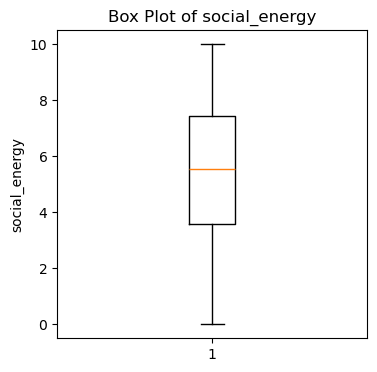

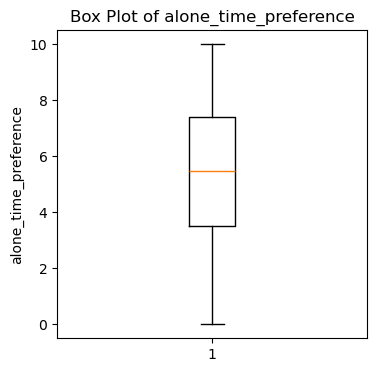

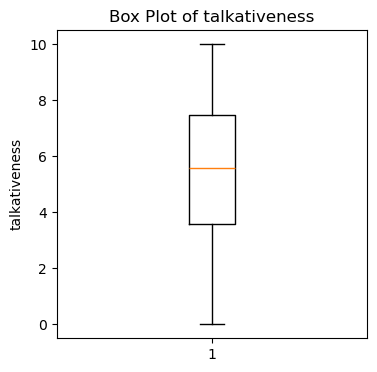

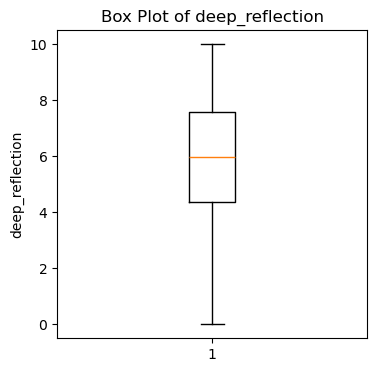

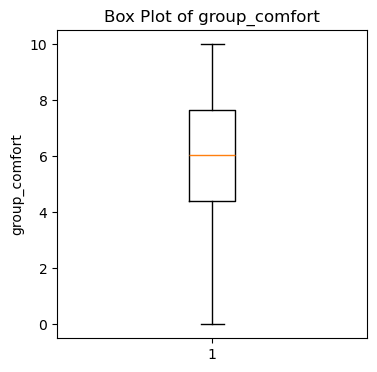

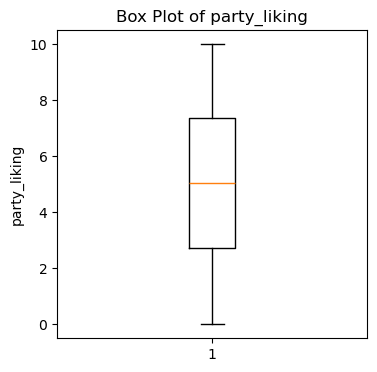

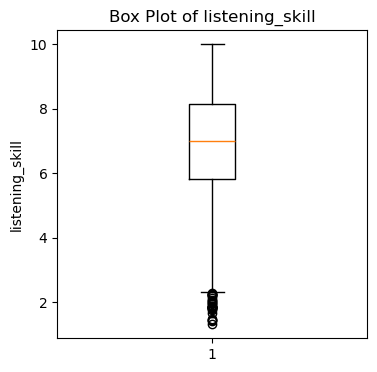

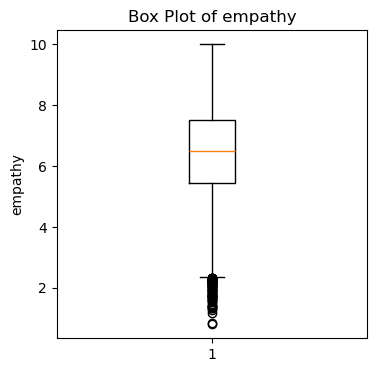

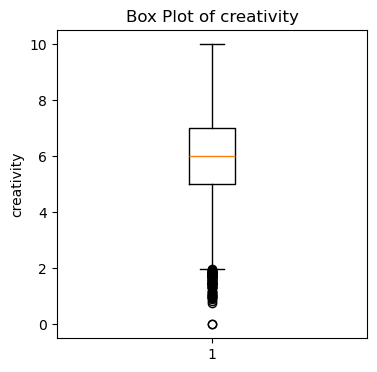

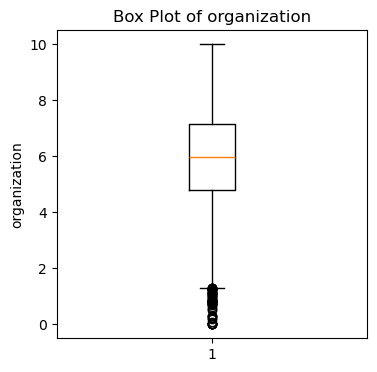

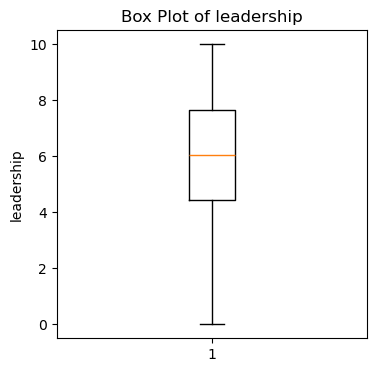

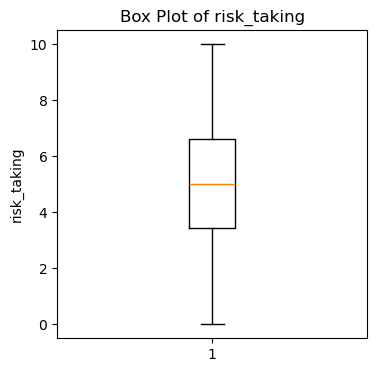

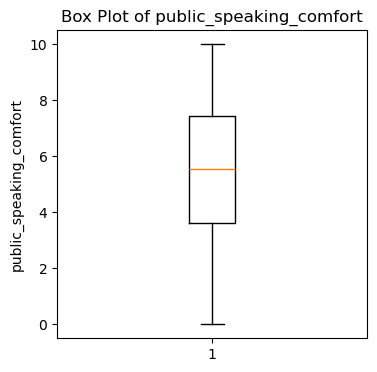

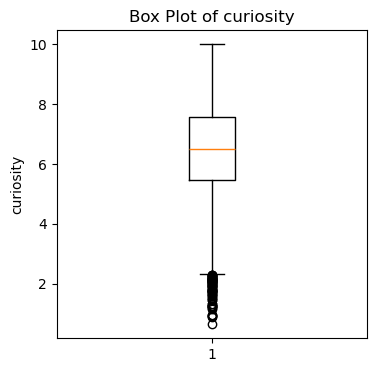

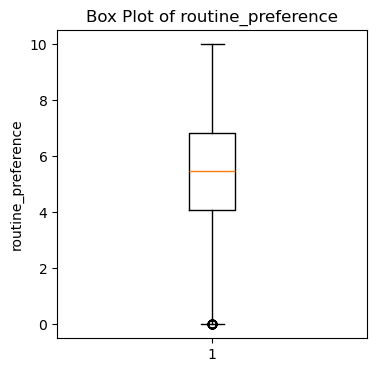

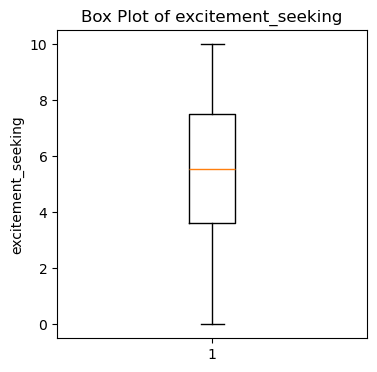

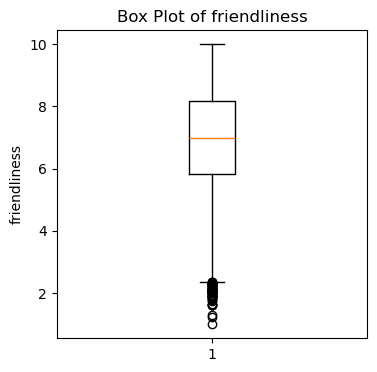

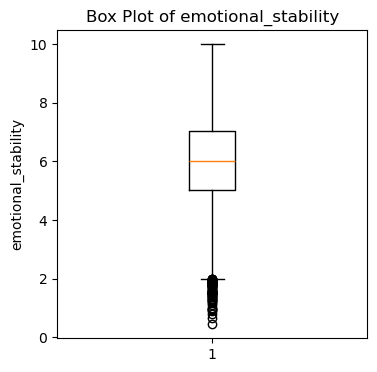

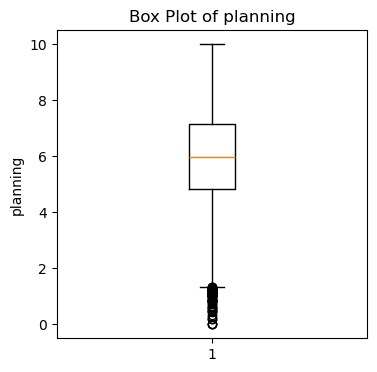

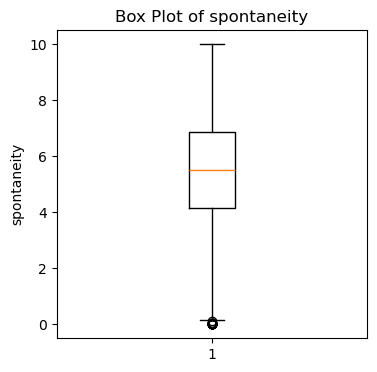

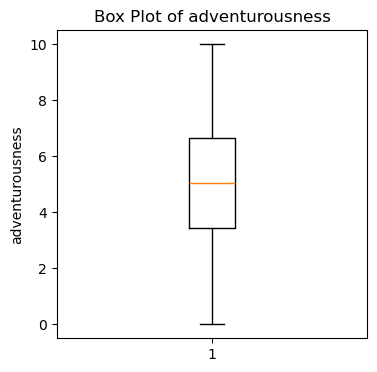

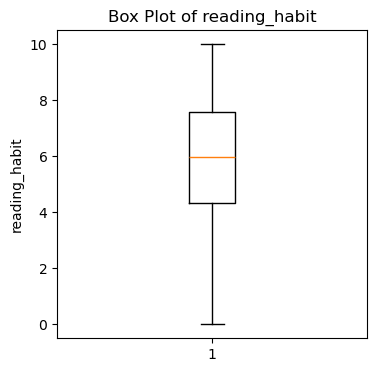

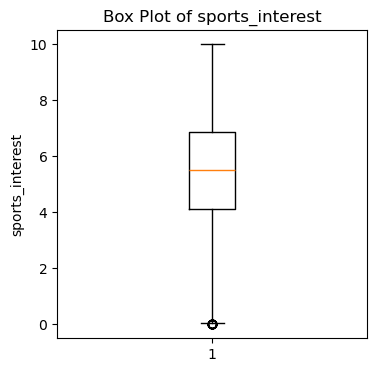

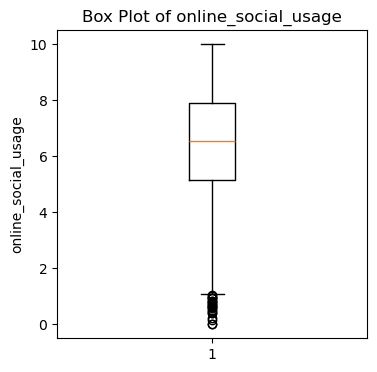

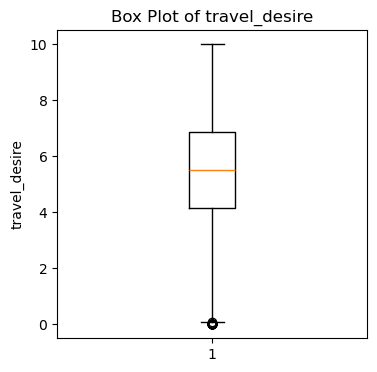

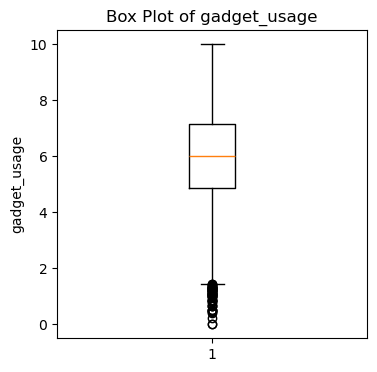

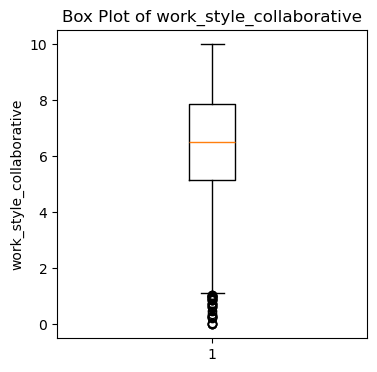

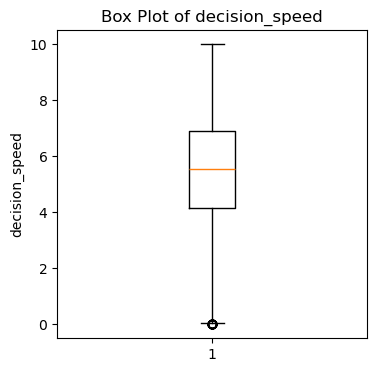

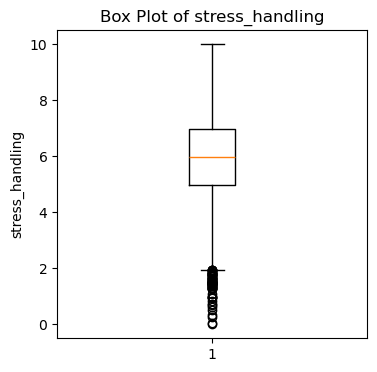

In [18]:
for col in numerical_columns:
    plt.figure(figsize=(4, 4))
    plt.boxplot(df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

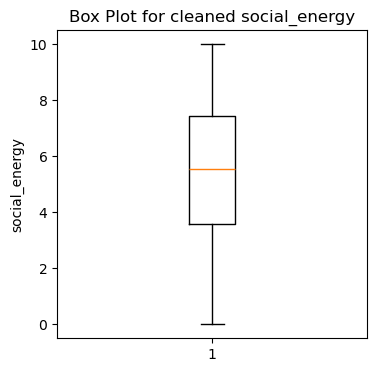

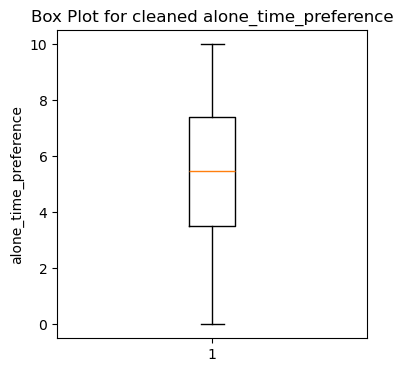

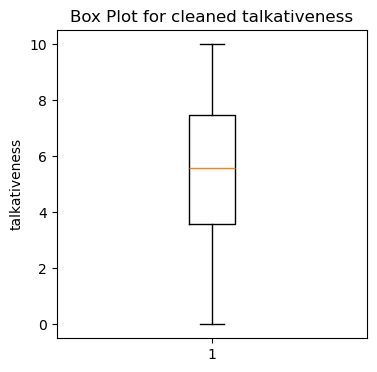

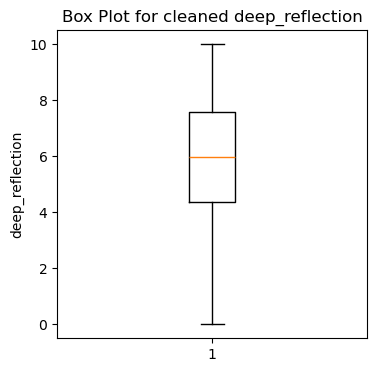

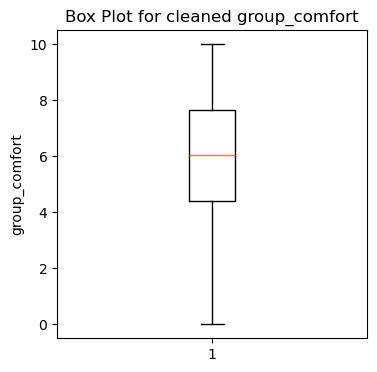

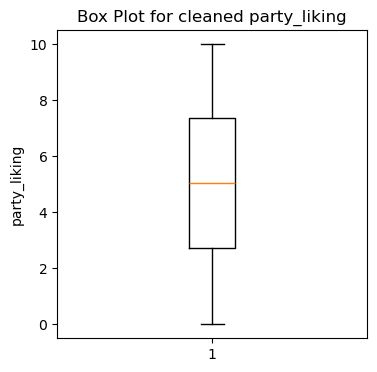

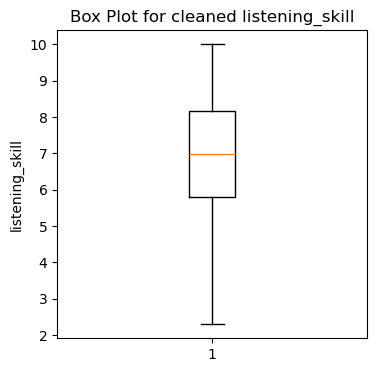

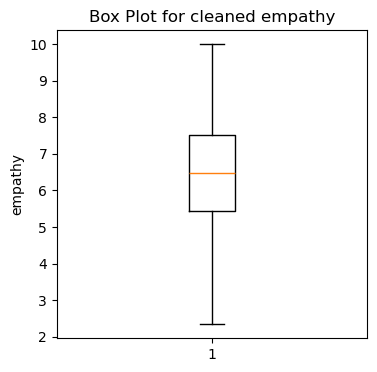

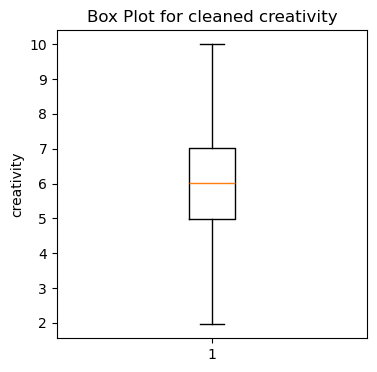

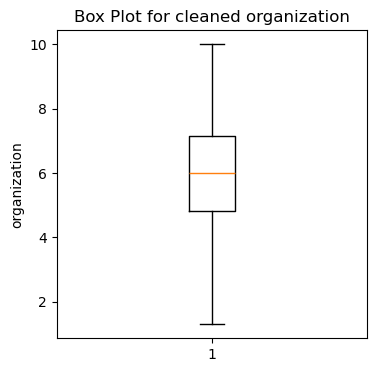

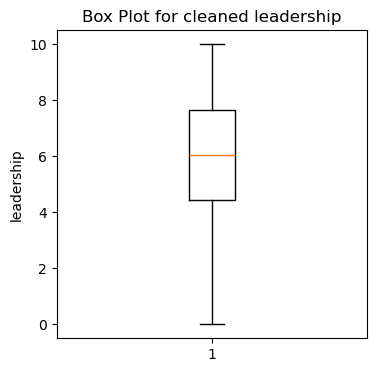

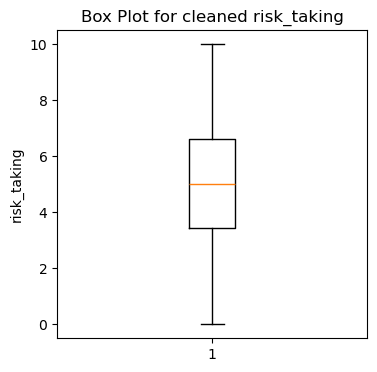

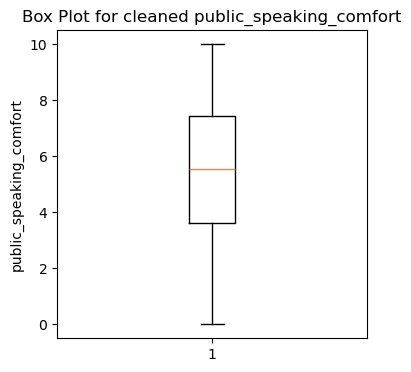

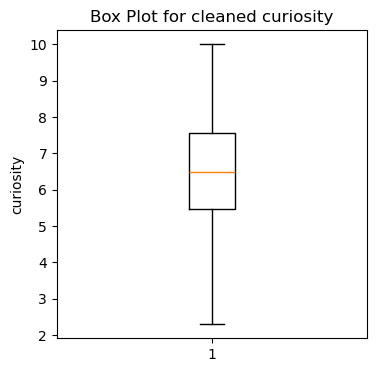

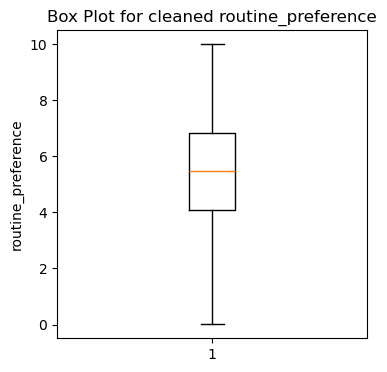

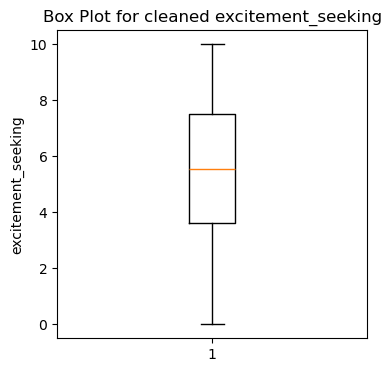

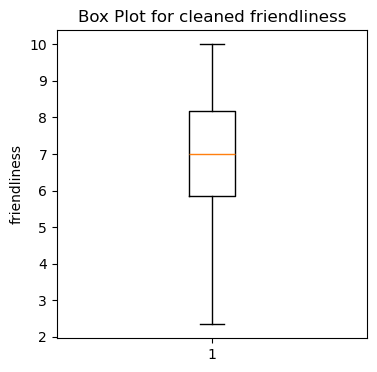

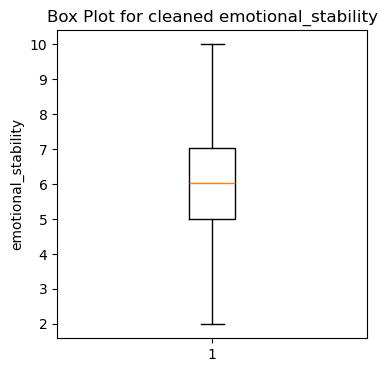

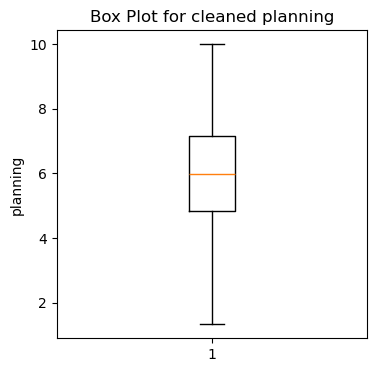

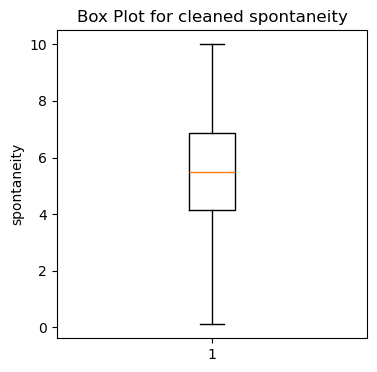

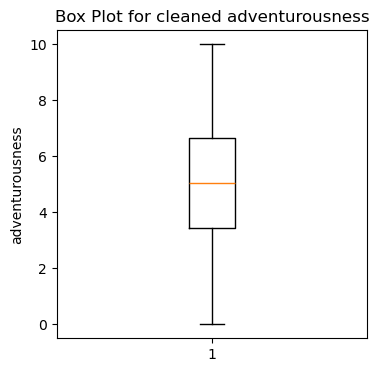

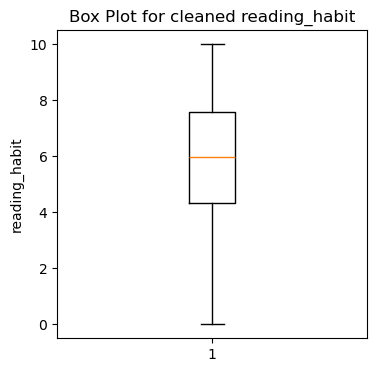

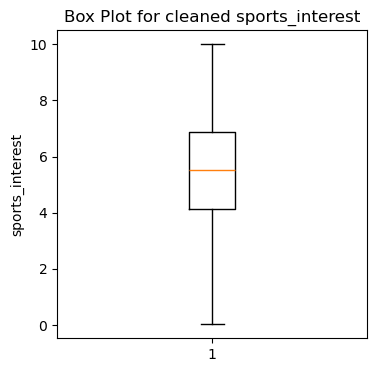

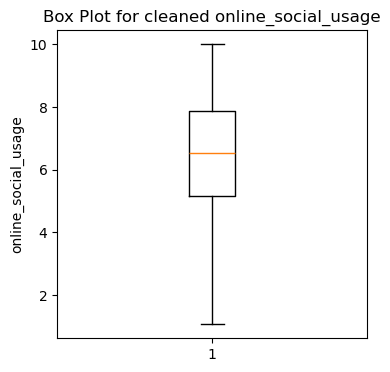

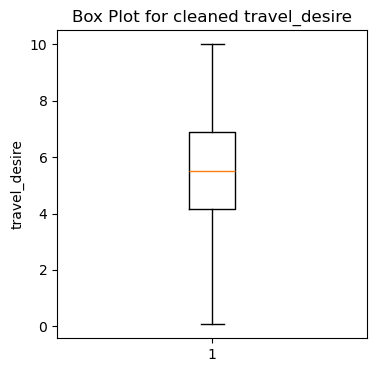

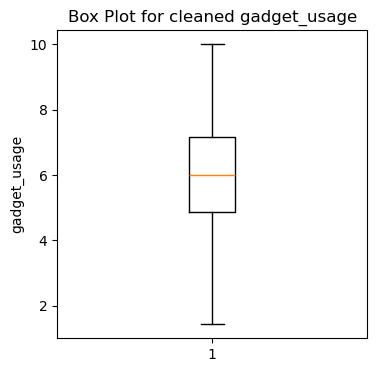

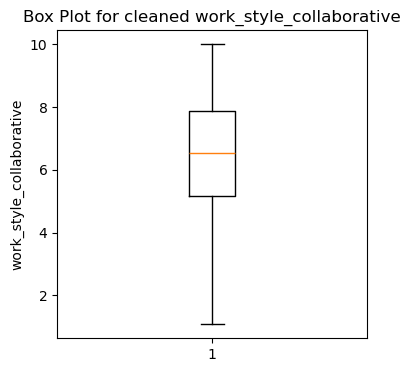

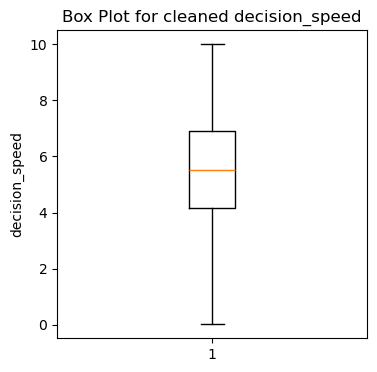

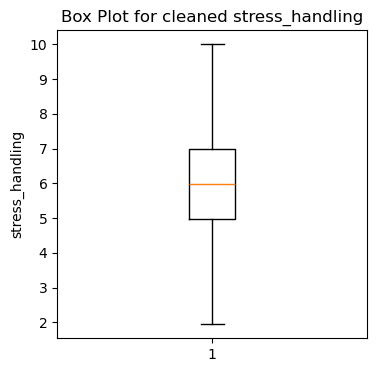

In [19]:
outliers=['listening_skill','empathy','creativity','organization','curiosity','routine_preference','friendliness','emotional_stability','planning',
          'spontaneity','sports_interest','online_social_usage','travel_desire','gadget_usage','work_style_collaborative','decision_speed',
          'stress_handling']
for col in outliers:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    # Replace values above upper with upper, below lower with lower
    df[col] = df[col].clip(lower, upper)
for col in numerical_columns:
    plt.figure(figsize=(4, 4))
    plt.boxplot(df[col])
    plt.title(f'Box Plot for cleaned {col}')
    plt.ylabel(col)
    plt.show()

# Exploratory Data Analysis (EDA)

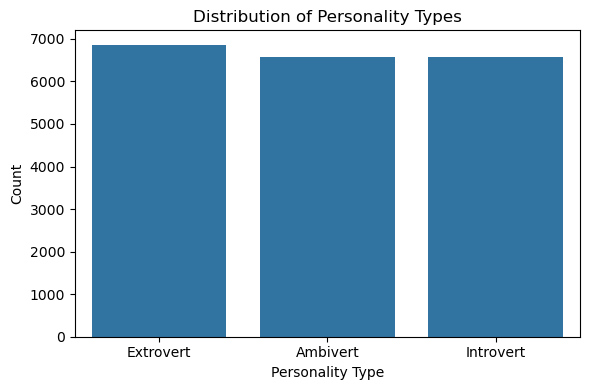

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x="personality_type", data=df)
plt.title("Distribution of Personality Types")
plt.xlabel("Personality Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
# Checks class balance

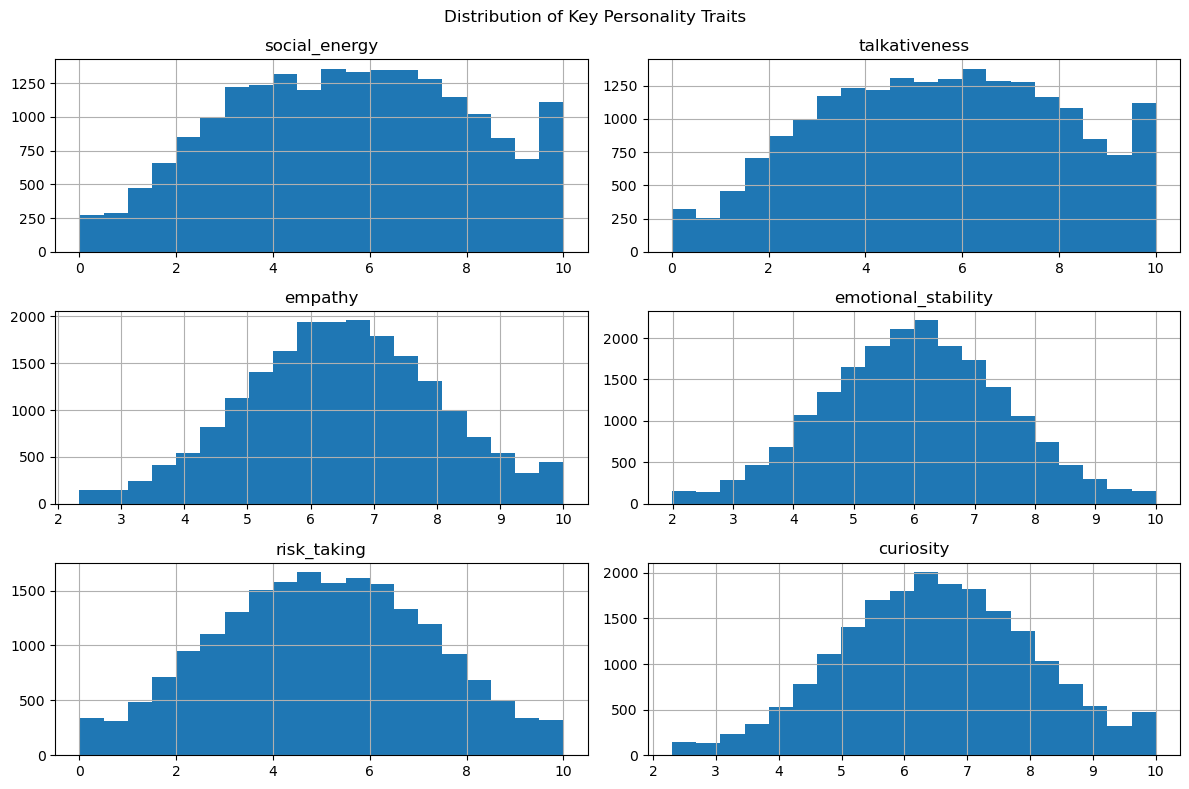

In [21]:
features = [
    "social_energy", "talkativeness", "empathy",
    "emotional_stability", "risk_taking", "curiosity"
]

df[features].hist(figsize=(12,8), bins=20)
plt.suptitle("Distribution of Key Personality Traits")
plt.tight_layout()
plt.show()


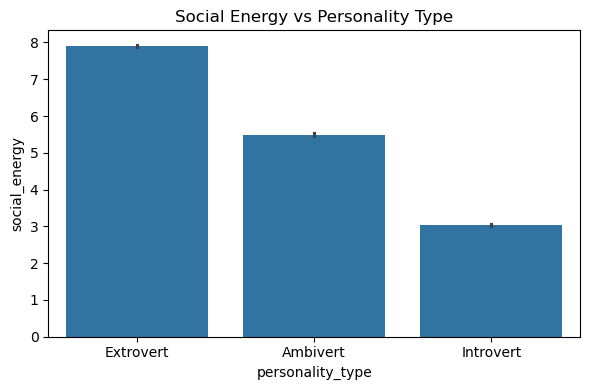

In [22]:
plt.figure(figsize=(6,4))
sns.barplot(x="personality_type", y="social_energy", data=df)
plt.title("Social Energy vs Personality Type")
plt.tight_layout()
plt.show()

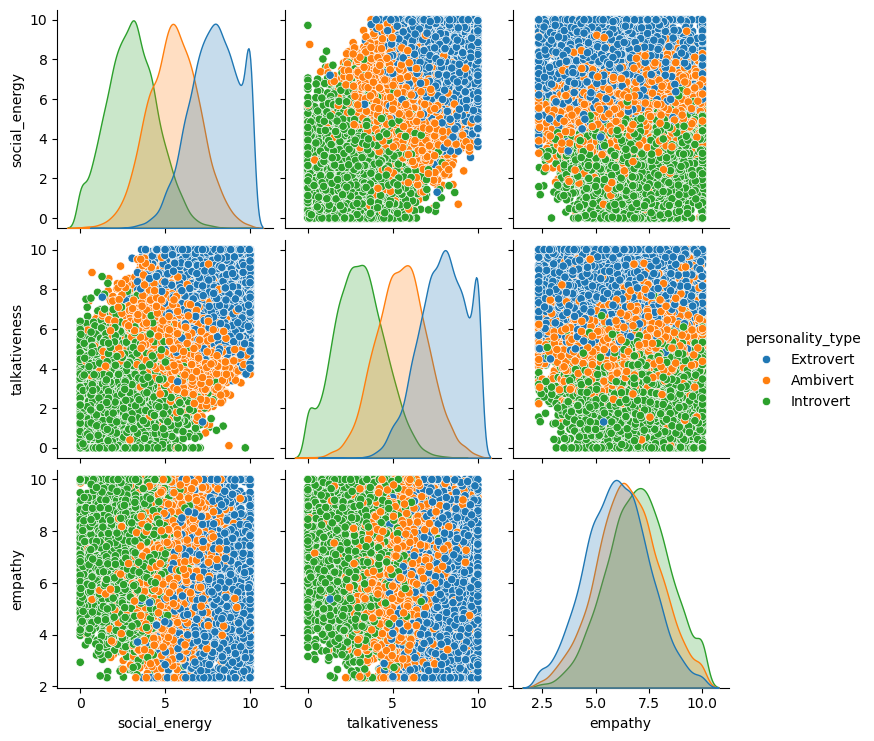

In [23]:
sns.pairplot(
    df,
    vars=["social_energy", "talkativeness", "empathy"],
    hue="personality_type"
)
plt.show()


# Encoding

In [24]:
a=LabelEncoder()
df['personality_type']=a.fit_transform(df['personality_type'])

# Correlation

In [25]:
correlation =df.corr()
correlation

,personality_type,social_energy,alone_time_preference,talkativeness,deep_reflection,group_comfort,party_liking,listening_skill,empathy,creativity,...,spontaneity,adventurousness,reading_habit,sports_interest,online_social_usage,travel_desire,gadget_usage,work_style_collaborative,decision_speed,stress_handling
personality_type,1.000000,-0.402364,0.400301,-0.405560,0.357261,-0.372727,-0.423245,0.229527,0.127249,-0.000502,...,-0.306977,-0.368678,0.359883,-0.315667,-0.313858,-0.310207,-0.238617,-0.311867,-0.320784,0.000273
social_energy,-0.402364,1.000000,-0.654726,0.657548,-0.595024,0.600819,0.696256,-0.391813,-0.210892,0.003591,...,0.516331,0.602295,-0.593950,0.515192,0.513792,0.505402,0.385359,0.505671,0.511341,-0.000847
alone_time_preference,0.400301,-0.654726,1.000000,-0.658442,0.598747,-0.606488,-0.702538,0.395194,0.209774,-0.001046,...,-0.518237,-0.599756,0.606381,-0.523278,-0.513069,-0.519691,-0.398469,-0.509483,-0.526792,0.001997
talkativeness,-0.405560,0.657548,-0.658442,1.000000,-0.595642,0.602341,0.699113,-0.397042,-0.206543,0.000927,...,0.510905,0.605093,-0.605081,0.523668,0.515581,0.511868,0.392391,0.513499,0.519042,-0.001949
deep_reflection,0.357261,-0.595024,0.598747,-0.595642,1.000000,-0.545189,-0.635852,0.359459,0.189621,0.007337,...,-0.459047,-0.543586,0.546049,-0.466194,-0.464535,-0.459100,-0.355617,-0.460869,-0.471003,0.002700
group_comfort,-0.372727,0.600819,-0.606488,0.602341,-0.545189,1.000000,0.643558,-0.368458,-0.189048,0.008552,...,0.468921,0.545587,-0.555507,0.479161,0.466928,0.464768,0.362713,0.475388,0.475914,-0.005192
party_liking,-0.423245,0.696256,-0.702538,0.699113,-0.635852,0.643558,1.000000,-0.414054,-0.221609,-0.000499,...,0.546391,0.635631,-0.640000,0.555681,0.539518,0.543893,0.414994,0.542405,0.549649,-0.012096
listening_skill,0.229527,-0.391813,0.395194,-0.397042,0.359459,-0.368458,-0.414054,1.000000,0.124768,-0.010485,...,-0.307116,-0.351502,0.357130,-0.307280,-0.307951,-0.307248,-0.238331,-0.300161,-0.298729,-0.008152
empathy,0.127249,-0.210892,0.209774,-0.206543,0.189621,-0.189048,-0.221609,0.124768,1.000000,-0.014093,...,-0.168187,-0.187174,0.194182,-0.164798,-0.160290,-0.164044,-0.125453,-0.173075,-0.167450,-0.003418
creativity,-0.000502,0.003591,-0.001046,0.000927,0.007337,0.008552,-0.000499,-0.010485,-0.014093,1.000000,...,0.001988,0.003649,0.003033,-0.001913,-0.008434,0.002735,0.000347,0.004120,0.001473,-0.000907


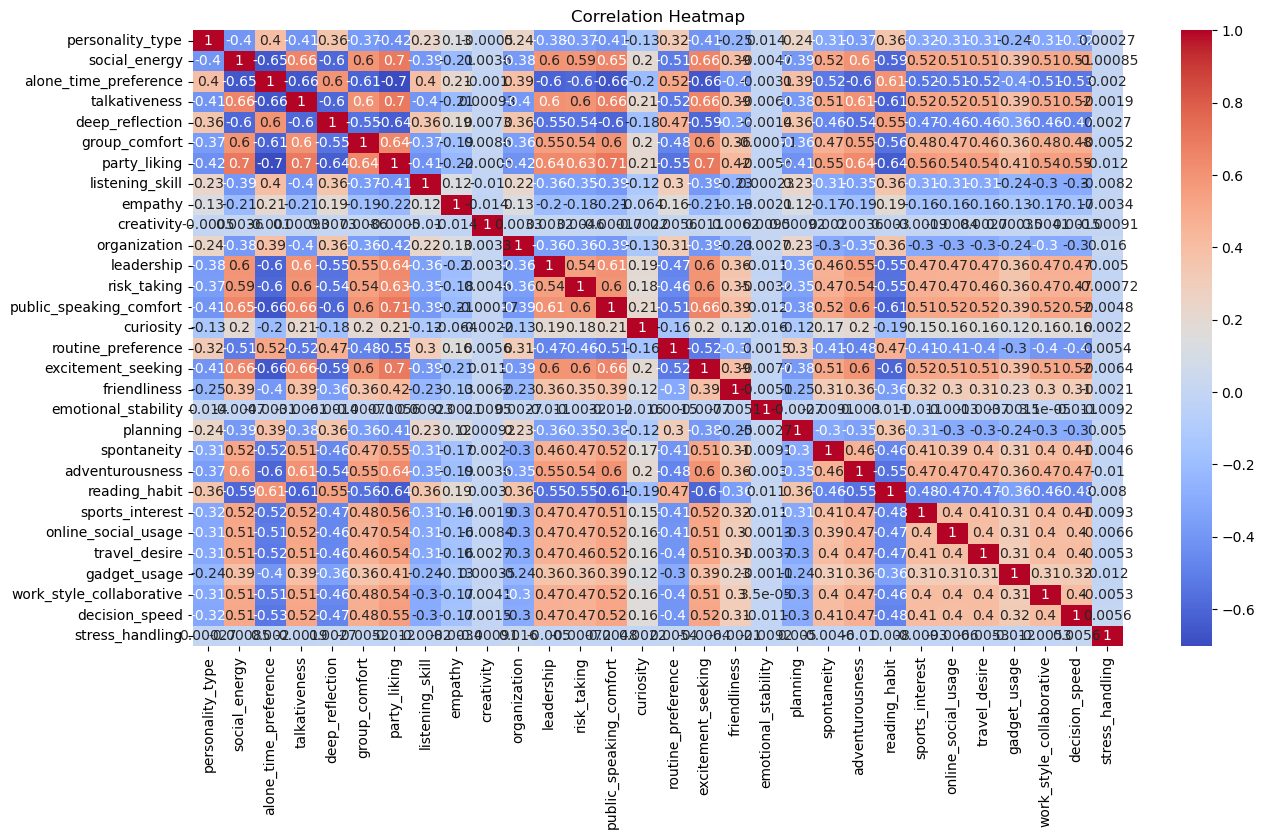

In [26]:
plt.figure(figsize=(15,8))
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [27]:
x=df.drop(columns=['personality_type'])
y=df['personality_type']

In [28]:
numerical_columns=['social_energy','alone_time_preference','talkativeness','deep_reflection','group_comfort','party_liking','listening_skill','empathy',
                   'creativity','organization','leadership','risk_taking','public_speaking_comfort','curiosity','routine_preference',
                   'excitement_seeking','friendliness','emotional_stability','planning','spontaneity','adventurousness','reading_habit',
                   'sports_interest','online_social_usage','travel_desire','gadget_usage','work_style_collaborative','decision_speed','stress_handling']

In [29]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [30]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train[numerical_columns])
x_test_scaled  = scaler.transform(x_test[numerical_columns])

# Modeling & Evaluation

In [31]:
lr= LogisticRegression()
lr.fit(x_train, y_train)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,roc_auc_score
y_pred=lr.predict(x_test)
print("predicted",y_pred)
print("actual:",y_test.values)
lr_test_acc = accuracy_score(y_test, y_pred)
print("Accuracy:\n",lr_test_acc)
lr_test_ps=precision_score(y_test, y_pred,average='weighted')
print("precision score:\n",lr_test_ps)
lr_test_rs=recall_score(y_test, y_pred,average='weighted')
print("recall score:\n",lr_test_rs)
lr_test_cm = confusion_matrix(y_test, y_pred)
print("confusion matrix:\n",lr_test_cm)
lr_test_f1=f1_score(y_test,y_pred,average='weighted')
print("f1 score:\n",lr_test_f1)

predicted [0 1 2 ... 2 2 0]
actual: [0 1 2 ... 2 2 0]
Accuracy:
 0.9948
precision score:
 0.994804851933157
recall score:
 0.9948
confusion matrix:
 [[1601    7    4]
 [   9 1761    0]
 [   6    0 1612]]
f1 score:
 0.9948016989141801


In [33]:
lr_y_test_prob = lr.predict_proba(x_test)[:, 1]

In [34]:
y_pred=lr.predict(x_train)
print("predicted",y_pred)
print("actual:",y_test.values)
lr_train_accuracy=accuracy_score(y_train,y_pred)
lr_train_accuracy

predicted [2 1 0 ... 2 0 2]
actual: [0 1 2 ... 2 2 0]


0.9974666666666666

In [35]:
############################
lr= LogisticRegression()
lr.fit(x_train_scaled, y_train)        
y_pred = lr.predict(x_test_scaled)     

lr_scaled_f1= f1_score(y_test, y_pred,average='weighted')             
print("R² score:", lr_scaled_f1)


R² score: 0.9976005820114721


In [36]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [37]:
y_pred=dt.predict(x_test)
print("predicted",y_pred)
print("actual:",y_test.values)
dt_test_acc = accuracy_score(y_test, y_pred)
print("Accuracy:\n",dt_test_acc)
dt_test_ps=precision_score(y_test, y_pred,average='weighted')
print("precision score:\n",dt_test_ps)
dt_test_rs=recall_score(y_test, y_pred,average='weighted')
print("recall score:\n",dt_test_rs)
dt_test_cm = confusion_matrix(y_test, y_pred)
print("confusion matrix:\n",dt_test_cm)
dt_test_f1=f1_score(y_test,y_pred,average='weighted')
print("f1 score:\n",dt_test_f1)

predicted [2 1 2 ... 2 2 0]
actual: [0 1 2 ... 2 2 0]
Accuracy:
 0.9448
precision score:
 0.9448416770889011
recall score:
 0.9448
confusion matrix:
 [[1476   75   61]
 [  72 1698    0]
 [  68    0 1550]]
f1 score:
 0.9448186825079025


In [38]:
dt_y_test_prob = dt.predict_proba(x_test)[:, 1]

In [39]:
y_pred=dt.predict(x_train)
print("predicted",y_pred)
print("actual:",y_test.values)
dt_train_accuracy=accuracy_score(y_train,y_pred)
dt_train_accuracy

predicted [2 1 0 ... 2 0 2]
actual: [0 1 2 ... 2 2 0]


1.0

In [40]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [41]:
y_pred=rf.predict(x_test)
print("predicted",y_pred)
print("actual:",y_test.values)
rf_test_acc = accuracy_score(y_test, y_pred)
print("Accuracy:\n",rf_test_acc)
rf_test_ps=precision_score(y_test, y_pred,average='weighted')
print("precision score:\n",rf_test_ps)
rf_test_rs=recall_score(y_test, y_pred,average='weighted')
print("recall score:\n",rf_test_rs)
rf_test_cm = confusion_matrix(y_test, y_pred)
print("confusion matrix:\n",rf_test_cm)
rf_test_f1=f1_score(y_test,y_pred,average='weighted')
print("f1 score:\n",rf_test_f1)

predicted [0 1 2 ... 2 2 0]
actual: [0 1 2 ... 2 2 0]
Accuracy:
 0.9954
precision score:
 0.9954029721362229
recall score:
 0.9954
confusion matrix:
 [[1602    5    5]
 [   5 1765    0]
 [   8    0 1610]]
f1 score:
 0.9954009318989337


In [42]:
rf_y_test_prob = rf.predict_proba(x_test)[:, 1]

In [43]:
y_pred=rf.predict(x_train)
print("predicted",y_pred)
print("actual:",y_test.values)
rf_train_accuracy=accuracy_score(y_train,y_pred)
rf_train_accuracy

predicted [2 1 0 ... 2 0 2]
actual: [0 1 2 ... 2 2 0]


1.0

In [44]:
gbc=GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=4,random_state=42)
gbc.fit(x_train,y_train)

GradientBoostingClassifier(max_depth=4, random_state=42)

In [45]:
y_pred=gbc.predict(x_test)
print("predicted",y_pred)
print("actual:",y_test.values)
gbc_test_acc = accuracy_score(y_test, y_pred)
print("Accuracy:\n",gbc_test_acc)
gbc_test_ps=precision_score(y_test, y_pred,average='weighted')
print("precision score:\n",gbc_test_ps)
gbc_test_rs=recall_score(y_test, y_pred,average='weighted')
print("recall score:\n",gbc_test_rs)
gbc_test_cm = confusion_matrix(y_test, y_pred)
print("confusion matrix:\n",gbc_test_cm)
gbc_test_f1=f1_score(y_test,y_pred,average='weighted')
print("f1 score:\n",gbc_test_f1)

predicted [0 1 2 ... 2 2 0]
actual: [0 1 2 ... 2 2 0]
Accuracy:
 0.9942
precision score:
 0.994208780472153
recall score:
 0.9942
confusion matrix:
 [[1600    4    8]
 [  10 1760    0]
 [   7    0 1611]]
f1 score:
 0.9942025770363638


In [46]:
gbc_y_test_prob = gbc.predict_proba(x_test)[:, 1]

In [47]:
y_pred=gbc.predict(x_train)
print("predicted",y_pred)
print("actual:",y_test.values)
gbc_train_accuracy=accuracy_score(y_train,y_pred)
gbc_train_accuracy

predicted [2 1 0 ... 2 0 2]
actual: [0 1 2 ... 2 2 0]


1.0

In [48]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [49]:
y_pred=knn.predict(x_test)
print("predicted",y_pred)
print("actual:",y_test.values)
knn_test_acc = accuracy_score(y_test, y_pred)
print("Accuracy:\n",knn_test_acc)
knn_test_ps=precision_score(y_test, y_pred,average='weighted')
print("precision score:\n",knn_test_ps)
knn_test_rs=recall_score(y_test, y_pred,average='weighted')
print("recall score:\n",knn_test_rs)
knn_test_cm = confusion_matrix(y_test, y_pred)
print("confusion matrix:\n",knn_test_cm)
knn_test_f1=f1_score(y_test,y_pred,average='weighted')
knn_test_f1

predicted [0 1 2 ... 2 2 0]
actual: [0 1 2 ... 2 2 0]
Accuracy:
 0.9972
precision score:
 0.9972014876022919
recall score:
 0.9972
confusion matrix:
 [[1606    4    2]
 [   4 1766    0]
 [   4    0 1614]]


0.9972004968904091

In [50]:
knn_y_test_prob = knn.predict_proba(x_test)[:, 1]

In [51]:
y_pred=knn.predict(x_train)
print("predicted",y_pred)
print("actual:",y_test.values)
knn_train_accuracy=accuracy_score(y_train,y_pred)
knn_train_accuracy

predicted [2 1 0 ... 2 0 2]
actual: [0 1 2 ... 2 2 0]


0.9978

In [52]:
gnb=GaussianNB()
gnb.fit(x_train,y_train)

GaussianNB()

In [53]:
y_pred=gnb.predict(x_test)
print("predicted",y_pred)
print("actual:",y_test.values)
gnb_test_acc = accuracy_score(y_test, y_pred)
print("Accuracy:\n",gnb_test_acc)
gnb_test_ps=precision_score(y_test, y_pred,average='weighted')
print("precision score:\n",gnb_test_ps)
gnb_test_rs=recall_score(y_test, y_pred,average='weighted')
print("recall score:\n",gnb_test_rs)
gnb_test_cm = confusion_matrix(y_test, y_pred)
print("confusion matrix:\n",gnb_test_cm)
gnb_test_f1=f1_score(y_test,y_pred,average='weighted')
gnb_test_f1

predicted [0 1 2 ... 2 2 0]
actual: [0 1 2 ... 2 2 0]
Accuracy:
 0.9974
precision score:
 0.9973996257201782
recall score:
 0.9974
confusion matrix:
 [[1605    4    3]
 [   4 1766    0]
 [   2    0 1616]]


0.9973997511130946

In [54]:
gnb_y_test_prob = gnb.predict_proba(x_test)[:, 1]

In [55]:
y_pred=gnb.predict(x_train)
print("predicted",y_pred)
print("actual:",y_test.values)
gnb_train_accuracy=accuracy_score(y_train,y_pred)
gnb_train_accuracy

predicted [2 1 0 ... 2 0 2]
actual: [0 1 2 ... 2 2 0]


0.9977333333333334

In [56]:
sc=SVC(kernel='linear',probability=True, random_state=42)
sc.fit(x_train,y_train)

SVC(kernel='linear', probability=True, random_state=42)

In [57]:
y_pred=sc.predict(x_test)
print("predicted",y_pred)
print("actual:",y_test.values)
sc_test_acc = accuracy_score(y_test, y_pred)
print("Accuracy:\n",sc_test_acc)
sc_test_ps=precision_score(y_test, y_pred,average='weighted')
print("precision score:\n",sc_test_ps)
sc_test_rs=recall_score(y_test, y_pred,average='weighted')
print("recall score:\n",sc_test_rs)
sc_test_cm = confusion_matrix(y_test, y_pred)
print("confusion matrix:\n",sc_test_cm)
sc_test_f1=f1_score(y_test,y_pred,average='weighted')
sc_test_f1

predicted [0 1 2 ... 2 2 0]
actual: [0 1 2 ... 2 2 0]
Accuracy:
 0.997
precision score:
 0.9970023249775292
recall score:
 0.997
confusion matrix:
 [[1606    3    3]
 [   6 1764    0]
 [   3    0 1615]]


0.9970006311252623

In [58]:
sc_y_test_prob = sc.predict_proba(x_test)[:, 1]

In [59]:
y_pred=sc.predict(x_train)
print("predicted",y_pred)
print("actual:",y_test.values)
sc_train_accuracy=accuracy_score(y_train,y_pred)
sc_train_accuracy

predicted [2 1 0 ... 2 0 2]
actual: [0 1 2 ... 2 2 0]


0.9990666666666667

In [60]:
##################
sc=SVC(kernel='linear')
sc.fit(x_train_scaled, y_train)        
y_pred = sc.predict(x_test_scaled)     

f1 = f1_score(y_test, y_pred,average='weighted')             
print("R² score:", f1)

R² score: 0.9972008298429466


# Model Selection

In [61]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "KNN",
        "Gaussian NB",
        "SVC"
    ],
    
    "Train Accuracy": [
        lr_train_accuracy,
        dt_train_accuracy,
        rf_train_accuracy,
        gbc_train_accuracy,
        knn_train_accuracy,
        gnb_train_accuracy,
        sc_train_accuracy
        
    ],

    "Test Accuracy": [
        lr_test_acc,
        dt_test_acc,
        rf_test_acc,
        gbc_test_acc,
        knn_test_acc,
        gnb_test_acc,
        sc_test_acc

    ],
    
    "Precision": [
        lr_test_ps,
        dt_test_ps,
        rf_test_ps,
        gbc_test_ps,
        knn_test_ps,
        gnb_test_ps,
        sc_test_ps
    ],
    
    "Recall": [
        lr_test_rs,
        dt_test_rs,
        rf_test_rs,
        gbc_test_rs,
        knn_test_rs,
        gnb_test_rs,
        sc_test_rs
    ],
    
    "F1 Score": [
        lr_test_f1,
        dt_test_f1,
        rf_test_f1,
        gbc_test_f1,
        knn_test_f1,
        gnb_test_f1,
        sc_test_f1
    ]
})
results.sort_values(by="F1 Score", ascending=False)
# Detect overfitting / underfitting
results["Accuracy Gap"] = results["Train Accuracy"] - results["Test Accuracy"]
results

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,Accuracy Gap
0,Logistic Regression,0.997467,0.9948,0.994805,0.9948,0.994802,0.002667
1,Decision Tree,1.000000,0.9448,0.944842,0.9448,0.944819,0.055200
2,Random Forest,1.000000,0.9954,0.995403,0.9954,0.995401,0.004600
3,Gradient Boosting,1.000000,0.9942,0.994209,0.9942,0.994203,0.005800
4,KNN,0.997800,0.9972,0.997201,0.9972,0.997200,0.000600
5,Gaussian NB,0.997733,0.9974,0.997400,0.9974,0.997400,0.000333
6,SVC,0.999067,0.9970,0.997002,0.9970,0.997001,0.002067


# Model Evaluation & Insights

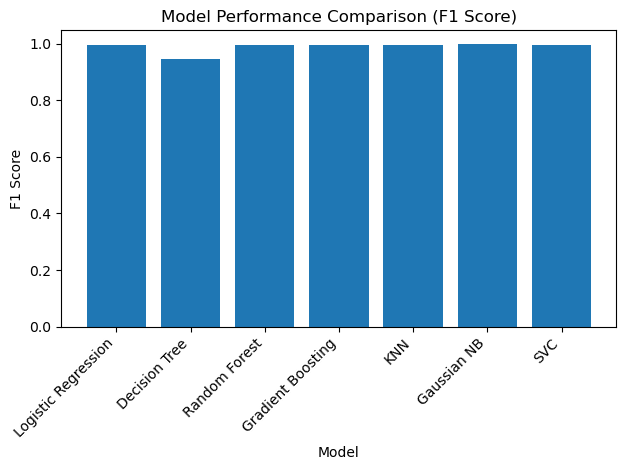

In [62]:
# 1️⃣ Model Performance Comparison Chart (F1 Score)
plt.figure()
plt.bar(results["Model"], results["F1 Score"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("Model Performance Comparison (F1 Score)")
plt.tight_layout()
plt.show()
# “The dataset is synthetic and well-separated, leading to very high performance across models.”

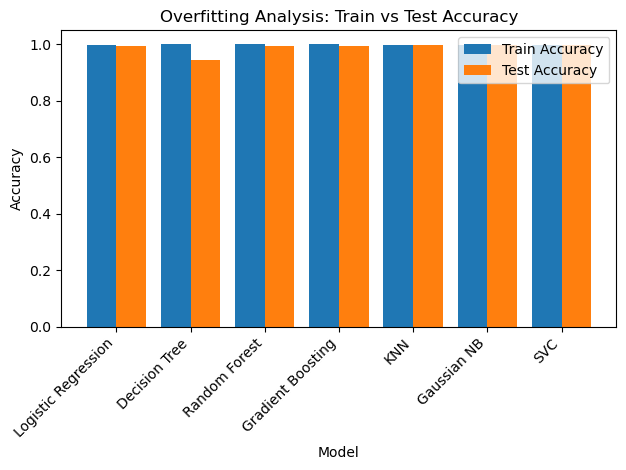

In [63]:
# 2️⃣ Overfitting Analysis
x = np.arange(len(results["Model"]))
plt.figure()
plt.bar(x - 0.2, results["Train Accuracy"], width=0.4, label="Train Accuracy")
plt.bar(x + 0.2, results["Test Accuracy"], width=0.4, label="Test Accuracy")
plt.xticks(x, results["Model"], rotation=45, ha="right")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Overfitting Analysis: Train vs Test Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Conclusion

In [64]:
all_models = {
    "LogisticRegression":lr,
    "DecisionTreeClassifier":dt,
    "Random Forest":rf,
    "GradientBoostingClassifier":gbc,
    "KNeighborsClassifier":knn,
    "GaussianNB":gnb,
    "SVC":sc
}
"LogisticRegression", "DecisionTreeClassifier", "Random Forest","GradientBoostingClassifier","KNeighborsClassifier","GaussianNB","SVC"

('LogisticRegression',
 'DecisionTreeClassifier',
 'Random Forest',
 'GradientBoostingClassifier',
 'KNeighborsClassifier',
 'GaussianNB',
 'SVC')

In [65]:
# Final selected model: GaussianNB
final_model=GaussianNB()
final_model.fit(x_train,y_train)

GaussianNB()

In [66]:
joblib.dump(final_model, "personality.pkl")

['personality.pkl']